In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/youssefaboelwafa/clustering-penguins-species/penguins.csv


In [3]:
data =  pd.read_csv('/kaggle/input/datasets/youssefaboelwafa/clustering-penguins-species/penguins.csv')

In [4]:
data.dropna(inplace =True)
data.drop(index=5,inplace =True)
data['sex']=data['sex'].map({'MALE':0,'FEMALE':1})

In [5]:
data.sample(7)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
192,49.0,19.5,210.0,3950.0,0.0
252,45.1,14.5,207.0,5050.0,1.0
52,35.0,17.9,190.0,3450.0,1.0
322,47.2,15.5,215.0,4975.0,1.0
55,41.4,18.6,191.0,3700.0,0.0
253,59.6,17.0,230.0,6050.0,0.0
19,46.0,21.5,194.0,4200.0,0.0


In [6]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
scaler  = RobustScaler()
data[['body_mass_g','flipper_length_mm']]= scaler.fit_transform(data[['body_mass_g','flipper_length_mm']])
data.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,-0.695652,-0.241206,0.0
1,39.5,17.4,-0.478261,-0.201005,1.0
2,40.3,18.0,-0.086957,-0.643216,1.0
4,36.7,19.3,-0.173913,-0.482412,1.0
6,38.9,17.8,-0.695652,-0.341709,1.0


<Axes: >

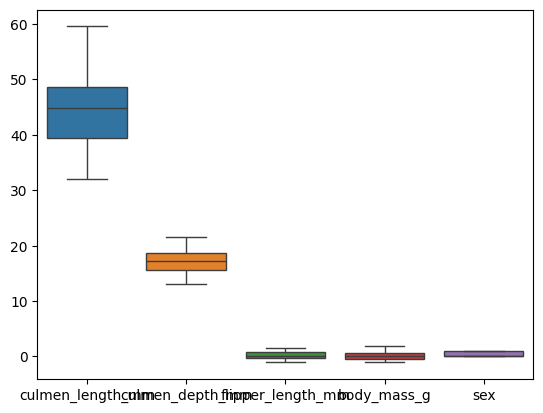

In [8]:
data.drop(index=[9,14],inplace =True)
data.reset_index(drop= True,inplace = True)
data.dropna(inplace = True)
sns.boxplot(data)


In [9]:
wcss=[]
for i in range (1,21):
    km =  KMeans(n_clusters =i)
    y_pred =  km.fit_predict(data)
    wcss.append(km.inertia_)

wcss

[11422.785906363473,
 3818.3175664733744,
 2455.025069407057,
 1828.2973716129445,
 1496.8621374092477,
 1223.8532443430415,
 1040.4172546154357,
 895.99912824576,
 778.5910657070641,
 806.3403539242663,
 672.7851809962606,
 620.3139803411161,
 603.920028754691,
 558.7965752207562,
 534.5074287003956,
 538.5622012182967,
 468.78436898319296,
 451.9155419588281,
 416.03003272957267,
 401.59513188559043]

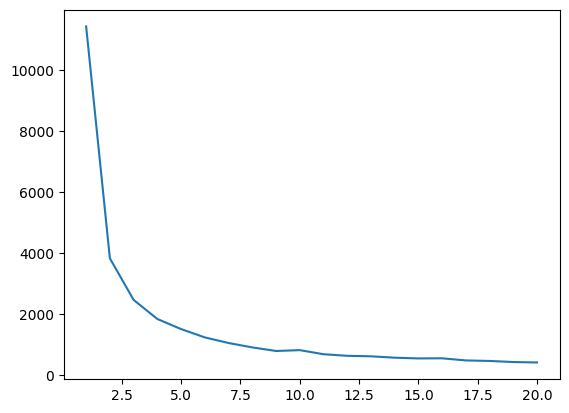

In [10]:
plt.plot(range(1,21),wcss)

In [11]:
X = data.iloc[:,:].values
km =  KMeans(n_clusters=5)
data['cluster']=km.fit_predict(data)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 331
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   331 non-null    float64
 1   culmen_depth_mm    331 non-null    float64
 2   flipper_length_mm  331 non-null    float64
 3   body_mass_g        331 non-null    float64
 4   sex                331 non-null    float64
 5   cluster            331 non-null    int32  
dtypes: float64(5), int32(1)
memory usage: 16.8 KB


In [17]:
#for plot we will use the principle component analysis (PCA) dimensionality reduction
pca =  PCA(n_components=2)
x_scaled =  pca.fit_transform(X)

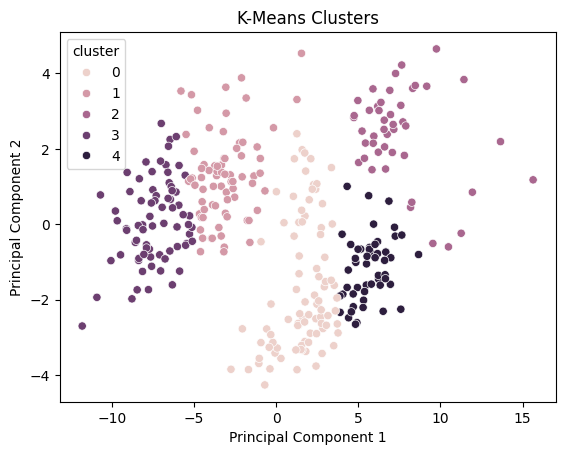

In [25]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],hue = data['cluster'])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()